In [2]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [3]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [5]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [04:34<00:00, 620kB/s]    
/Users/a1111/GO_PROJECTS/db/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [7]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [8]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1308641].


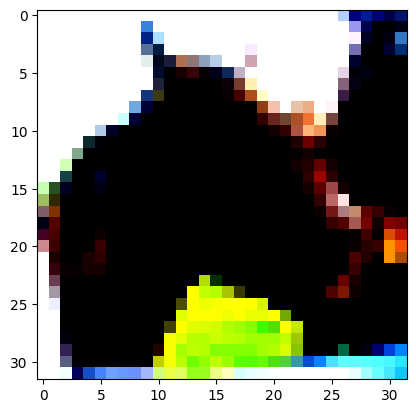

In [9]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [26]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [11]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [12]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [29]:
class Trainer:
    def __init__(self, config, transform=None):
        self.config = config
        self.transform = transform

        if torch.cuda.is_available():
            self.device = 'cuda'
        elif torch.backends.mps.is_available():
            self.device = 'mps'
        else:
            self.device = 'cpu'

        self.model = BasicCNN().to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.setup_dataloaders()

        self.history = {
            'train_acc': [],
            'val_acc': [],
            'test_acc': [],
        }

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        ne = self.config['num_epochs']
        for epoch in range(ne):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            test_loss, test_acc = self.test()
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['test_acc'].append(test_acc)

            print(
                f'Epoch {epoch + 1} / {ne}',
                f'train_loss={train_loss:.4f} train_acc={train_acc:.2f}',
                f'val_loss={val_loss:.4f} val_acc={val_acc:.2f}',
                f'test_loss={test_loss:.4f} test_acc={test_acc:.2f}',
            )

        final_test_acc = self.history['test_acc'][-1]
        print(f'Final test acc (last epoch): {final_test_acc:.2f}')

        return self.history, final_test_acc

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

In [30]:
trainer = Trainer(config, transform=transform)

In [31]:
basic_history, basic_test_acc = trainer.run()

100%|██████████| 79/79 [00:01<00:00, 77.56it/s]


Epoch 1 / 10 train_loss=1.7899 train_acc=33.40 val_loss=1.5317 val_acc=43.75 test_loss=1.5141 test_acc=44.84


100%|██████████| 79/79 [00:01<00:00, 68.74it/s]


Epoch 2 / 10 train_loss=1.5054 train_acc=45.39 val_loss=1.4616 val_acc=46.78 test_loss=1.4726 test_acc=46.53


100%|██████████| 79/79 [00:01<00:00, 75.62it/s]


...

Epoch 8 / 10 train_loss=1.1467 train_acc=58.44 val_loss=1.2522 val_acc=55.12 test_loss=1.2622 test_acc=54.71


100%|██████████| 79/79 [00:01<00:00, 78.04it/s]


Epoch 9 / 10 train_loss=1.1281 train_acc=59.19 val_loss=1.2383 val_acc=55.52 test_loss=1.2545 test_acc=54.86


100%|██████████| 79/79 [00:01<00:00, 75.45it/s]

Epoch 10 / 10 train_loss=1.1137 train_acc=59.72 val_loss=1.2340 val_acc=55.57 test_loss=1.2501 test_acc=55.13
Final test acc (last epoch): 55.13


# ResNet-18

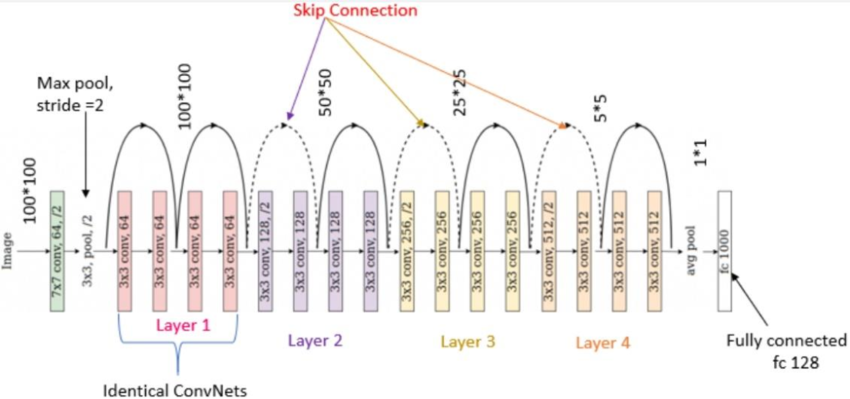

In [32]:
class ResNetBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
        downsample=None
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):

        identity = x

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity

        out = F.relu(out)

        return out

In [33]:
class ResNet18(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.in_channels = 64

        # CIFAR10 version
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)

        self.max_pool = nn.Identity()

        self.layer1 = self.make_layer(
            out_channels=64,
            blocks=2,
            stride=1
        )

        self.layer2 = self.make_layer(
            out_channels=128,
            blocks=2,
            stride=2
        )

        self.layer3 = self.make_layer(
            out_channels=256,
            blocks=2,
            stride=2
        )

        self.layer4 = self.make_layer(
            out_channels=512,
            blocks=2,
            stride=2
        )

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(512, num_classes)

    def make_layer(
        self,
        out_channels,
        blocks,
        stride=1
    ):

        downsample = None

        if stride != 1 or self.in_channels != out_channels:

            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

        layers = []

        layers.append(
            ResNetBlock(
                self.in_channels,
                out_channels,
                stride,
                downsample
            )
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):

            layers.append(
                ResNetBlock(
                    self.in_channels,
                    out_channels
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.max_pool(x)

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.layer3(x)

        x = self.layer4(x)

        x = self.avg_pool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [18]:
# Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN

In [34]:
class Trainer:

    def __init__(self, model, config, transform=None):

        self.config = config
        self.transform = transform

        if torch.cuda.is_available():
            self.device = 'cuda'
        elif torch.backends.mps.is_available():
            self.device = 'mps'
        else:
            self.device = 'cpu'

        self.model = model.to(self.device)

        self.optimizer = Adam(
            self.model.parameters(),
            lr=self.config['lr']
        )

        self.scheduler = StepLR(
            self.optimizer,
            step_size=5,
            gamma=0.1
        )

        self.loss_function = nn.CrossEntropyLoss()

        self.setup_dataloaders()

        self.history = {
            'train_acc': [],
            'val_acc': [],
            'test_acc': [],
        }

    def setup_dataloaders(self):

        train_dataset_full = CIFAR10(
            root='cifar10',
            train=True,
            download=True,
            transform=self.transform
        )

        test_dataset = CIFAR10(
            root='cifar10',
            train=False,
            download=True,
            transform=self.transform
        )

        train_indices, val_indices = train_test_split(
            list(range(len(train_dataset_full))),
            test_size=self.config['test_size'],
            random_state=42,
            shuffle=True
        )

        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(
            train_dataset,
            batch_size=self.config['batch_size'],
            shuffle=True
        )

        self.val_loader = DataLoader(
            val_dataset,
            batch_size=self.config['batch_size'],
            shuffle=False
        )

        self.test_loader = DataLoader(
            test_dataset,
            batch_size=self.config['batch_size'],
            shuffle=False
        )

    def train_step(self):

        self.model.train()

        correct = 0
        total = 0

        for images, labels in tqdm(self.train_loader):

            images = images.to(self.device)
            labels = labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)

            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

        acc = 100 * correct / total

        return acc

    def val_step(self):

        self.model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in tqdm(self.val_loader):

                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)

                preds = torch.argmax(outputs, dim=1)

                correct += (preds == labels).sum().item()

                total += labels.size(0)

        acc = 100 * correct / total

        return acc

    def test(self):

        self.model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in tqdm(self.test_loader):

                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)

                preds = torch.argmax(outputs, dim=1)

                correct += (preds == labels).sum().item()

                total += labels.size(0)

        acc = 100 * correct / total

        return acc

    def run(self):

        for epoch in range(self.config['num_epochs']):

            train_acc = self.train_step()

            val_acc = self.val_step()

            test_acc = self.test()

            self.history['train_acc'].append(train_acc)

            self.history['val_acc'].append(val_acc)

            self.history['test_acc'].append(test_acc)

            print(
                f'Epoch {epoch+1}: '
                f'train_acc={train_acc:.2f}, '
                f'val_acc={val_acc:.2f}, '
                f'test_acc={test_acc:.2f}'
            )

        final_test_acc = self.history['test_acc'][-1]

        print(f'Final test accuracy: {final_test_acc:.2f}')

        return self.history, final_test_acc

In [35]:
resnet_model = ResNet18()

trainer_resnet = Trainer(
    model=resnet_model,
    config=config,
    transform=transform
)

resnet_history, resnet_test_acc = trainer_resnet.run()

100%|██████████| 79/79 [00:04<00:00, 18.52it/s]


Epoch 1: train_acc=33.38, val_acc=45.68, test_acc=46.08


100%|██████████| 79/79 [00:04<00:00, 19.33it/s]


Epoch 2: train_acc=51.94, val_acc=58.19, test_acc=58.34


100%|██████████| 79/79 [00:04<00:00, 19.35it/s]


...

Epoch 8: train_acc=90.55, val_acc=79.98, test_acc=79.23


100%|██████████| 79/79 [00:04<00:00, 19.20it/s]


Epoch 9: train_acc=93.35, val_acc=79.22, test_acc=78.66


100%|██████████| 79/79 [00:04<00:00, 19.37it/s]

Epoch 10: train_acc=95.01, val_acc=78.61, test_acc=77.99
Final test accuracy: 77.99


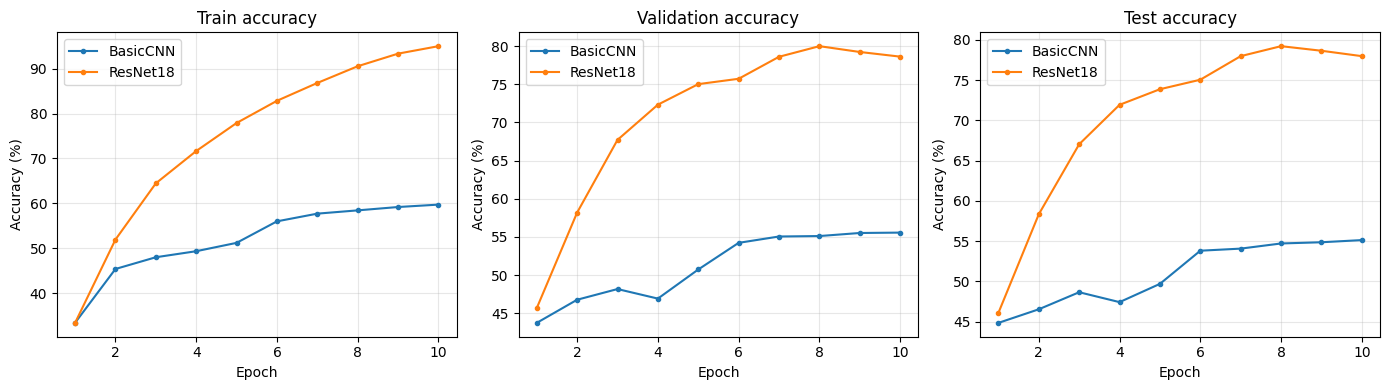

BasicCNN — последняя test accuracy: 55.13%
ResNet18 — последняя test accuracy: 77.99%


In [36]:
import numpy as np

epochs = np.arange(1, len(basic_history['train_acc']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

titles = ['Train', 'Validation', 'Test']
keys = ['train_acc', 'val_acc', 'test_acc']

for ax, title, key in zip(axes, titles, keys):
    ax.plot(epochs, basic_history[key], label='BasicCNN', marker='o', markersize=3)
    ax.plot(epochs, resnet_history[key], label='ResNet18', marker='o', markersize=3)
    ax.set_title(f'{title} accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'BasicCNN — последняя test accuracy: {basic_test_acc:.2f}%')
print(f'ResNet18 — последняя test accuracy: {resnet_test_acc:.2f}%')